# Portfolio Evaluation: CNN-GARCH vs Baselines

Ce notebook implémente l'**évaluation financière** du modèle CNN-GARCH hybride.  
Au lieu de mesurer la précision statistique (log-MSE), on mesure la **qualité de l'allocation de portefeuille**.

## Pipeline
```
Returns (N stocks) → Modèle → σ_i (annualisée ×252) → W_i = (1/σ²_i)/Σ(1/σ²_j)
                                                           ↓
                                            r_portfolio = Σ(W_i × r_i)
                                                           ↓
                                            σ_portfolio, Sharpe, Drawdown
```

## Stratégies comparées
| Stratégie | Description |
|-----------|-------------|
| **NN-GARCH** | σ prédite par le CNN hybride (notre modèle) |
| **Hist-Vol** | Volatilité historique rolling (fenêtre glissante) |
| **EWMA** | Volatilité exponentielle pondérée (RiskMetrics λ=0.94) |
| **ARCH(1,1)** | Modèle ARCH classique fitté sur le train |
| **Equal-Weight** | 1/N benchmark |

**Référence superviseur** :  
- Annualisation : ×252  
- W = (1/σ²) / Σ(1/σ²)  
- Loss cible : MSE(σ_pred, |r|)  
- r_portfolio = Σ(r_it × W_i)

## 1. Imports & Configuration

In [38]:
from __future__ import annotations

import warnings
import sys
import time

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec

warnings.filterwarnings('ignore')
sys.path.insert(0, '.')

from model import HybridGarch
from data_stocks_WIKI_price import get_cleaned_data

print(f"PyTorch {torch.__version__}")
print(f"NumPy   {np.__version__}")
print(f"Pandas  {pd.__version__}")

PyTorch 2.10.0+cpu
NumPy   2.4.2
Pandas  2.3.3


In [39]:
# ── Configuration ────────────────────────────────────────────────────────────
FILE_PATH   = r"C:/Users/karim/OneDrive/Documents/Msc AI/Finance/TP/WIKI_PRICES_212b326a081eacca455e13140d7bb9db.zip"
CHECKPOINT  = "finetune_real_zeroaware_r2min1e8_best.pt"   # meilleur checkpoint
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

WINDOW_SIZE = 90      # fenêtre d'entrée du CNN (même que l'entraînement)
N_STOCKS    = 30      # nombre d'actions dans le portefeuille
TRAIN_RATIO = 0.70    # 70% train / 30% test (out-of-sample)
ANNUALIZE   = 252     # jours de trading par an

EWMA_LAMBDA = 0.94    # paramètre RiskMetrics EWMA
REFIT_ARCH  = False   # True = ARCH re-fitté (très lent), False = fit unique sur train

print(f"Device     : {DEVICE}")
print(f"Checkpoint : {CHECKPOINT}")
print(f"Window     : {WINDOW_SIZE} | Stocks : {N_STOCKS} | Train : {int(TRAIN_RATIO*100)}%")

Device     : cpu
Checkpoint : finetune_real_zeroaware_r2min1e8_best.pt
Window     : 90 | Stocks : 30 | Train : 70%


## 2. Chargement des données

In [40]:
print("Loading WIKI Prices data...")
returns_df_full = get_cleaned_data(FILE_PATH)
print(f"Full universe : {returns_df_full.shape[0]} days × {returns_df_full.shape[1]} stocks")
print(f"Date range    : {returns_df_full.index[0].date()} → {returns_df_full.index[-1].date()}")

# Sélection des N_STOCKS actions (déjà filtrées pour être complètes)
selected = returns_df_full.columns[:N_STOCKS].tolist()
returns_df = returns_df_full[selected].copy()
print(f"\nPortefeuille : {N_STOCKS} actions")
print(f"Tickers      : {selected[:10]} ...")

Loading WIKI Prices data...
Full universe : 4585 days × 1390 stocks
Date range    : 2000-01-04 → 2018-03-27

Portefeuille : 30 actions
Tickers      : ['A', 'AAN', 'AAON', 'AAPL', 'ABAX', 'ABC', 'ABCB', 'ABM', 'ABMD', 'ABT'] ...


In [41]:
# ── Train / Test split ───────────────────────────────────────────────────────
n_total   = len(returns_df)
split_idx = int(TRAIN_RATIO * n_total)

returns_train = returns_df.iloc[:split_idx]
returns_test  = returns_df.iloc[split_idx:]

# Statistiques par action calculées sur le train uniquement
train_means = returns_train.mean().values.astype(np.float32)  # [N_STOCKS]
train_stds  = returns_train.std(ddof=0).values.astype(np.float32)  # [N_STOCKS]

print(f"Train : {returns_train.index[0].date()} → {returns_train.index[-1].date()} ({len(returns_train)} jours)")
print(f"Test  : {returns_test.index[0].date()} → {returns_test.index[-1].date()} ({len(returns_test)} jours)")

Train : 2000-01-04 → 2012-10-03 (3209 jours)
Test  : 2012-10-04 → 2018-03-27 (1376 jours)


## 3. Chargement du modèle CNN-GARCH

In [42]:
model = HybridGarch(hidden=32, kernel=3, conv_layers=5)
model.load_state_dict(torch.load(CHECKPOINT, map_location=DEVICE))
model.to(DEVICE)
model.eval()

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Modèle chargé : {CHECKPOINT}")
print(f"Paramètres    : {n_params:,}")
print(f"Device        : {DEVICE}")

Modèle chargé : finetune_real_zeroaware_r2min1e8_best.pt
Paramètres    : 14,499
Device        : cpu


## 4. Fonctions d'estimation de volatilité

Pour chaque méthode, on estime $\sigma^2_i(t)$ **annualisée** $= \sigma^2_{daily} \times 252$.

In [43]:
@torch.no_grad()
def _predict_nn_batch(windows_norm: np.ndarray, model: torch.nn.Module,
                      device: torch.device) -> np.ndarray:
    """Forward pass batché : [N_stocks, W] → σ²_norm [N_stocks]."""
    x = torch.tensor(windows_norm, dtype=torch.float32, device=device).unsqueeze(-1)  # [N, W, 1]
    sigma2_norm, _, _, _ = model(x)
    return sigma2_norm.cpu().numpy()


def precompute_sigma2_nn(returns_arr: np.ndarray,
                         train_means: np.ndarray, train_stds: np.ndarray,
                         model: torch.nn.Module, device: torch.device,
                         window_size: int, start_t: int,
                         annualize: int = 252) -> np.ndarray:
    """
    Pour chaque t ∈ [start_t, T), prédit σ² annualisée pour toutes les actions
    en une seule passe batché (toutes actions simultanément).
    Retourne [T - start_t, N_stocks].
    """
    T, N = returns_arr.shape
    test_len = T - start_t
    sigma2_mat = np.full((test_len, N), np.nan)

    eps = 1e-8
    for k, t in enumerate(range(start_t, T)):
        windows = returns_arr[t - window_size:t, :]  # [W, N]
        if np.isnan(windows).any():
            continue
        # Normalisation par stock (train stats)
        windows_T = windows.T  # [N, W]
        windows_norm = (windows_T - train_means[:, None]) / (train_stds[:, None] + eps)

        s2_norm = _predict_nn_batch(windows_norm, model, device)  # [N]
        s2_real = s2_norm * (train_stds + eps) ** 2               # rescale
        sigma2_mat[k] = np.clip(s2_real, 1e-10, None) * annualize

    return sigma2_mat


def precompute_sigma2_hist(returns_arr: np.ndarray,
                           window_size: int, start_t: int,
                           annualize: int = 252) -> np.ndarray:
    """Volatilité historique rolling. Retourne [test_len, N_stocks]."""
    T, N = returns_arr.shape
    test_len = T - start_t
    sigma2_mat = np.zeros((test_len, N))

    for k, t in enumerate(range(start_t, T)):
        window = returns_arr[t - window_size:t, :]
        std_vals = np.nanstd(window, axis=0, ddof=0)
        sigma2_mat[k] = std_vals ** 2 * annualize

    return sigma2_mat


def precompute_sigma2_ewma(returns_arr: np.ndarray,
                           lam: float, start_t: int,
                           annualize: int = 252) -> np.ndarray:
    """
    EWMA RiskMetrics : σ²[t] = λ·σ²[t-1] + (1-λ)·r²[t-1].
    Retourne [test_len, N_stocks].
    """
    T, N = returns_arr.shape
    test_len = T - start_t
    sigma2_mat = np.zeros((test_len, N))

    # Initialisation : variance sur les 30 premiers jours
    s2 = np.var(returns_arr[:30, :], axis=0, ddof=0)
    s2 = np.maximum(s2, 1e-10)

    for t in range(1, T):
        s2 = lam * s2 + (1 - lam) * returns_arr[t - 1, :] ** 2
        if t >= start_t:
            k = t - start_t
            sigma2_mat[k] = s2 * annualize

    return sigma2_mat


def precompute_sigma2_arch(returns_arr: np.ndarray,
                           train_means: np.ndarray,
                           split_idx: int, start_t: int,
                           annualize: int = 252) -> np.ndarray:
    """
    ARCH(1,1) fitté une fois sur le train, puis récursion forward pour le test.
    Retourne [test_len, N_stocks].
    """
    from arch import arch_model as arch_fit

    T, N = returns_arr.shape
    test_len = T - start_t
    sigma2_mat = np.zeros((test_len, N))

    r_train = returns_arr[:split_idx, :]

    for j in range(N):
        r_j = r_train[:, j].astype(np.float64)
        try:
            am  = arch_fit(r_j * 100, mean='Zero', vol='GARCH', p=1, q=1, dist='normal')
            res = am.fit(disp='off')
            omega_j = res.params['omega'] / (100 ** 2)
            alpha_j = res.params['alpha[1]']
            beta_j  = res.params['beta[1]']
            init_s2 = float(res.conditional_volatility[-1] ** 2)
        except Exception:
            # Fallback si fit échoue
            omega_j, alpha_j, beta_j = 1e-6, 0.05, 0.90
            init_s2 = np.var(r_j, ddof=0)

        # Récursion forward sur [split_idx, T)
        s2 = init_s2
        for t in range(split_idx, T):
            r_prev = returns_arr[t - 1, j]
            s2 = omega_j + alpha_j * r_prev ** 2 + beta_j * s2
            s2 = max(s2, 1e-10)
            if t >= start_t:
                sigma2_mat[t - start_t, j] = s2 * annualize

    return sigma2_mat


print("Fonctions d'estimation définies.")

Fonctions d'estimation définies.


## 5. Précalcul des matrices de volatilité

Pour chaque méthode et chaque jour du **test set**, on calcule $\sigma^2_i(t)$ annualisée pour toutes les actions.

In [44]:
returns_arr = returns_df.values.astype(np.float32)  # [T, N]
start_t = max(WINDOW_SIZE, split_idx)                # premier jour où on peut prédire
test_dates = returns_df.index[start_t:]

print(f"Précalcul sur {len(test_dates)} jours de test, {N_STOCKS} actions...")
print(f"(start_t = {start_t}, correspondant à {returns_df.index[start_t].date()})\n")

# ── NN-GARCH ─────────────────────────────────────────────────────────────────
print("[1/4] NN-GARCH (forward pass batché)...")
t0 = time.time()
sigma2_nn = precompute_sigma2_nn(
    returns_arr, train_means, train_stds,
    model, DEVICE, WINDOW_SIZE, start_t, ANNUALIZE
)
print(f"      OK — {time.time()-t0:.1f}s")

# ── Hist-Vol ──────────────────────────────────────────────────────────────────
print("[2/4] Historical Volatility...")
t0 = time.time()
sigma2_hist = precompute_sigma2_hist(returns_arr, WINDOW_SIZE, start_t, ANNUALIZE)
print(f"      OK — {time.time()-t0:.1f}s")

# ── EWMA ─────────────────────────────────────────────────────────────────────
print("[3/4] EWMA (RiskMetrics λ=0.94)...")
t0 = time.time()
sigma2_ewma = precompute_sigma2_ewma(returns_arr, EWMA_LAMBDA, start_t, ANNUALIZE)
print(f"      OK — {time.time()-t0:.1f}s")

# ── ARCH(1,1) ────────────────────────────────────────────────────────────────
print("[4/4] ARCH(1,1) (fit sur train + récursion)...")
t0 = time.time()
sigma2_arch = precompute_sigma2_arch(
    returns_arr.astype(np.float64), train_means, split_idx, start_t, ANNUALIZE
)
print(f"      OK — {time.time()-t0:.1f}s")

print("\nToutes les matrices σ² calculées.")
print(f"Shape de chaque matrice : {sigma2_nn.shape}  [test_days × N_stocks]")

Précalcul sur 1376 jours de test, 30 actions...
(start_t = 3209, correspondant à 2012-10-04)

[1/4] NN-GARCH (forward pass batché)...
      OK — 7.4s
[2/4] Historical Volatility...
      OK — 0.1s
[3/4] EWMA (RiskMetrics λ=0.94)...
      OK — 0.0s
[4/4] ARCH(1,1) (fit sur train + récursion)...
      OK — 0.8s

Toutes les matrices σ² calculées.
Shape de chaque matrice : (1376, 30)  [test_days × N_stocks]


## 6. Construction du portefeuille

Poids d'allocation inverse de la variance :
$$W_i(t) = \frac{1/\sigma^2_i(t)}{\sum_j 1/\sigma^2_j(t)}$$

Return du portefeuille :
$$r_{\text{portfolio}}(t) = \sum_i W_i(t) \cdot r_i(t)$$

In [45]:
def inverse_variance_weights(sigma2: np.ndarray, eps: float = 1e-10) -> np.ndarray:
    """W_i = (1/σ²_i) / Σ(1/σ²_j). Gère les NaN en les remplaçant par la moyenne."""
    s2 = sigma2.copy()
    nan_mask = np.isnan(s2) | (s2 <= 0)
    if nan_mask.all():
        return np.ones(len(s2)) / len(s2)
    # Remplacer NaN par la moyenne des valeurs valides
    s2[nan_mask] = np.nanmean(s2[~nan_mask])
    inv_var = 1.0 / np.maximum(s2, eps)
    return inv_var / inv_var.sum()


def compute_portfolio_returns(sigma2_mat: np.ndarray,
                               returns_arr: np.ndarray,
                               start_t: int,
                               strategy: str = 'inv-var') -> tuple[np.ndarray, np.ndarray]:
    """
    Calcule les returns journaliers du portefeuille et les poids.
    Returns:
        port_returns : [test_len]  — returns journaliers
        weights_hist : [test_len, N_stocks] — poids à chaque jour
    """
    test_len = sigma2_mat.shape[0]
    N = sigma2_mat.shape[1]
    port_returns = np.zeros(test_len)
    weights_hist = np.zeros((test_len, N))

    for k in range(test_len):
        t = start_t + k
        r_t = returns_arr[t]  # returns réalisés au jour t

        if strategy == 'inv-var':
            w = inverse_variance_weights(sigma2_mat[k])
        else:  # equal-weight
            w = np.ones(N) / N

        port_returns[k] = np.dot(w, r_t)
        weights_hist[k] = w

    return port_returns, weights_hist


# ── Calcul des returns pour chaque stratégie ────────────────────────────────
test_len = len(test_dates)

print("Construction des portefeuilles...")

r_nn,   w_nn   = compute_portfolio_returns(sigma2_nn,   returns_arr, start_t)
r_hist, w_hist = compute_portfolio_returns(sigma2_hist, returns_arr, start_t)
r_ewma, w_ewma = compute_portfolio_returns(sigma2_ewma, returns_arr, start_t)
r_arch, w_arch = compute_portfolio_returns(sigma2_arch, returns_arr, start_t)
r_eq,   w_eq   = compute_portfolio_returns(sigma2_nn,   returns_arr, start_t, strategy='equal')

# DataFrame des returns journaliers
port_returns = pd.DataFrame({
    'NN-GARCH'     : r_nn,
    'Hist-Vol'     : r_hist,
    'EWMA'         : r_ewma,
    'ARCH(1,1)'    : r_arch,
    'Equal-Weight' : r_eq,
}, index=test_dates)

print(f"Returns calculés — {len(port_returns)} jours de test.")
print("\nMoyenne des returns journaliers (%) :")
print((port_returns.mean() * 100).round(4).to_string())

Construction des portefeuilles...
Returns calculés — 1376 jours de test.

Moyenne des returns journaliers (%) :
NN-GARCH        0.0752
Hist-Vol        0.0737
EWMA            0.0741
ARCH(1,1)       0.0773
Equal-Weight    0.0754


## 7. Métriques financières

In [46]:
def financial_metrics(returns: pd.Series, annualize: int = 252) -> dict:
    """Calcule les métriques clés d'un portefeuille."""
    r = returns.dropna()

    ann_ret = r.mean() * annualize
    ann_vol = r.std(ddof=0) * np.sqrt(annualize)
    sharpe  = ann_ret / ann_vol if ann_vol > 1e-10 else np.nan

    cumret      = (1 + r).cumprod()
    rolling_max = cumret.cummax()
    drawdown    = (cumret - rolling_max) / rolling_max
    max_dd      = float(drawdown.min())

    calmar = ann_ret / abs(max_dd) if abs(max_dd) > 1e-10 else np.nan

    # Turnover moyen (approximatif via vol journalière des returns)
    daily_vol_pct = ann_vol / np.sqrt(annualize) * 100

    return {
        'Ann. Return (%)'   : round(ann_ret * 100, 3),
        'Ann. Volatility (%)': round(ann_vol * 100, 3),
        'Sharpe Ratio'      : round(sharpe, 4),
        'Max Drawdown (%)'  : round(max_dd * 100, 3),
        'Calmar Ratio'      : round(calmar, 4),
        'Daily Vol (%)'     : round(daily_vol_pct, 4),
    }


metrics = pd.DataFrame(
    {col: financial_metrics(port_returns[col], ANNUALIZE) for col in port_returns.columns}
).T

print("=" * 70)
print("PERFORMANCE DU PORTEFEUILLE — OUT-OF-SAMPLE")
print("=" * 70)
print(metrics.to_string())
print("=" * 70)

# Rang par volatilité (critère principal : minimiser σ_portfolio)
print("\nClassement par volatilité annualisée (objectif : minimiser) :")
rank = metrics['Ann. Volatility (%)'].sort_values()
for i, (name, val) in enumerate(rank.items(), 1):
    marker = " ← MEILLEUR" if i == 1 else ""
    print(f"  {i}. {name:<18} {val:.3f}%{marker}")

PERFORMANCE DU PORTEFEUILLE — OUT-OF-SAMPLE
              Ann. Return (%)  Ann. Volatility (%)  Sharpe Ratio  Max Drawdown (%)  Calmar Ratio  Daily Vol (%)
NN-GARCH               18.943               12.076        1.5687           -13.682        1.3846         0.7607
Hist-Vol               18.572               12.138        1.5301           -11.303        1.6431         0.7646
EWMA                   18.679               12.128        1.5401           -13.229        1.4119         0.7640
ARCH(1,1)              19.487               11.987        1.6256           -12.710        1.5332         0.7551
Equal-Weight           18.997               14.065        1.3507           -14.653        1.2965         0.8860

Classement par volatilité annualisée (objectif : minimiser) :
  1. ARCH(1,1)          11.987% ← MEILLEUR
  2. NN-GARCH           12.076%
  3. EWMA               12.128%
  4. Hist-Vol           12.138%
  5. Equal-Weight       14.065%


## 8. Visualisations

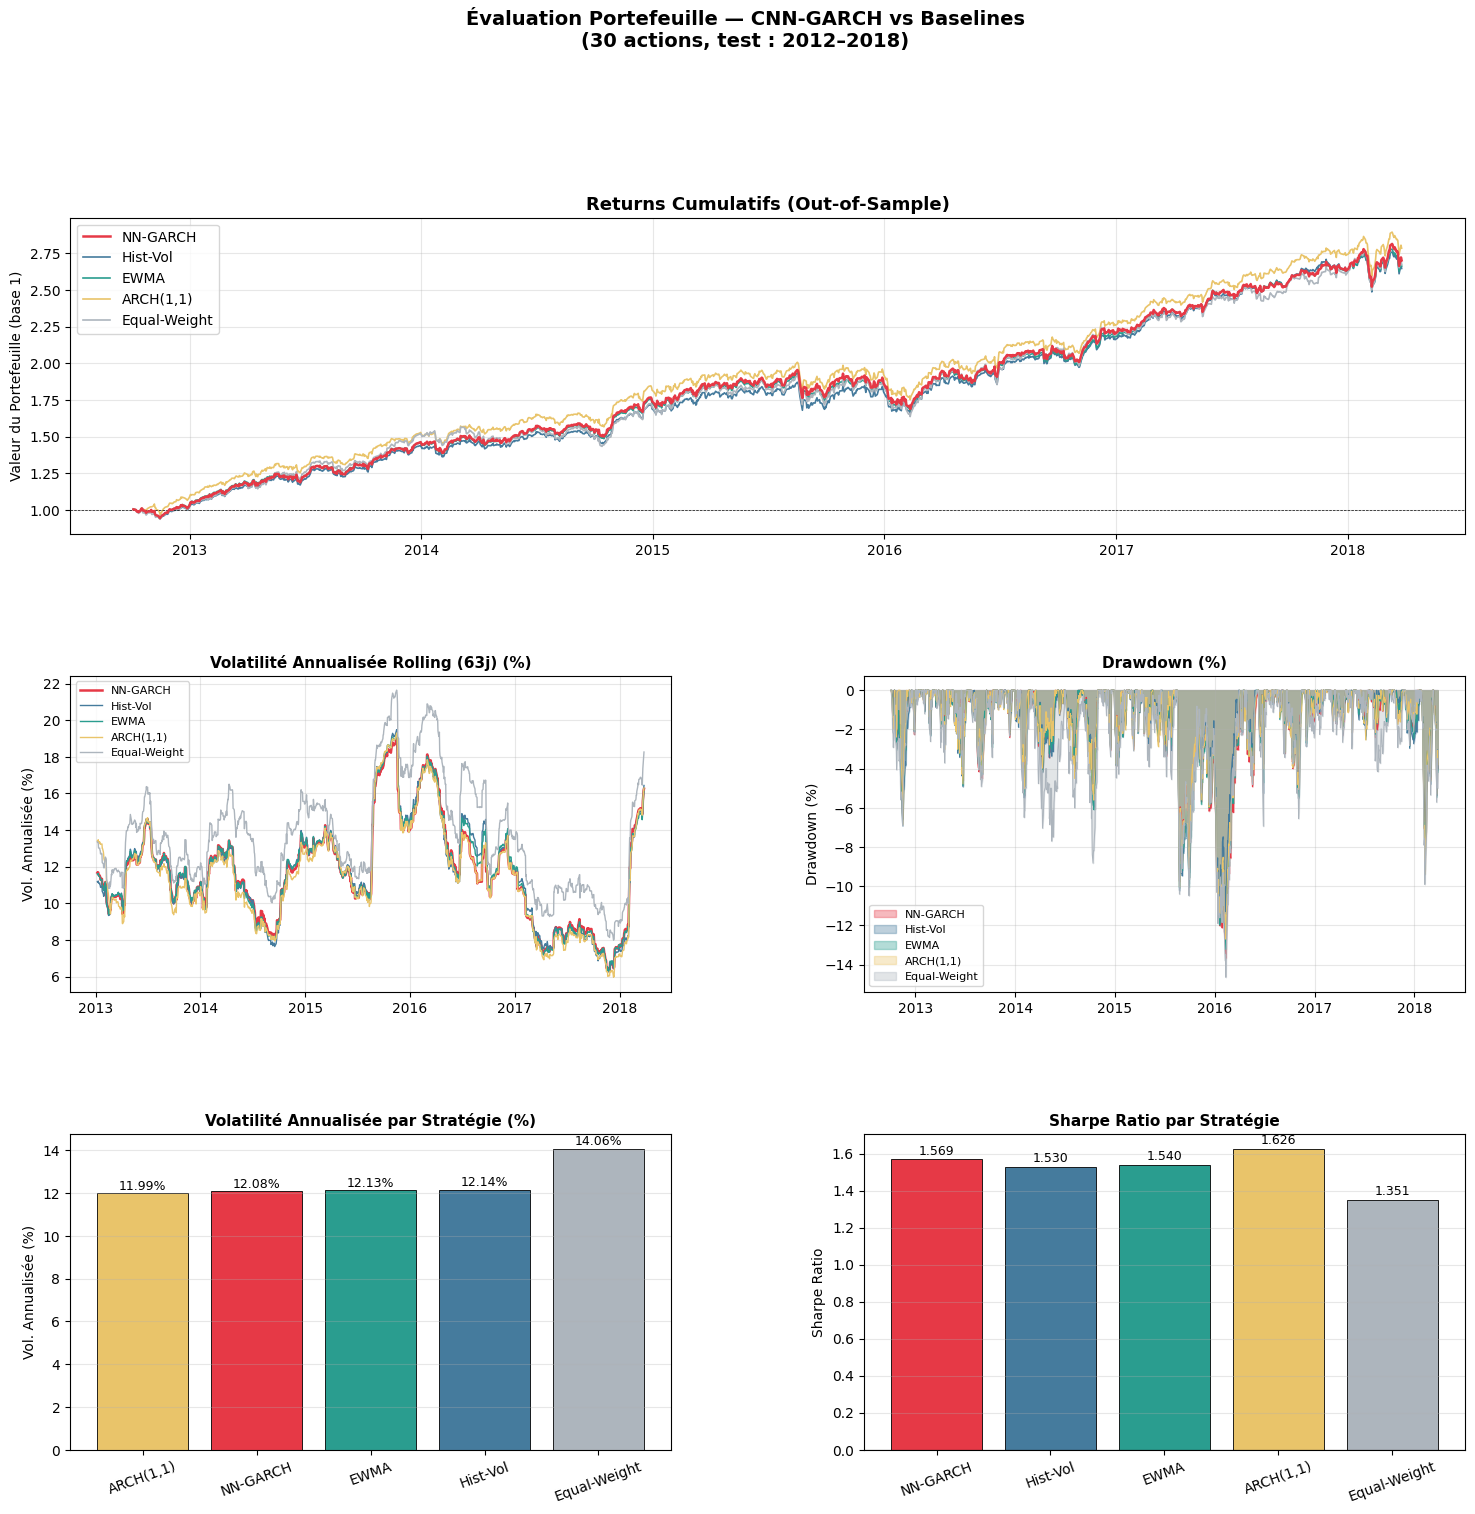

Figure sauvegardée : portfolio_comparison.png


In [47]:
COLORS = {
    'NN-GARCH'     : '#e63946',
    'Hist-Vol'     : '#457b9d',
    'EWMA'         : '#2a9d8f',
    'ARCH(1,1)'    : '#e9c46a',
    'Equal-Weight' : '#adb5bd',
}
STRATEGIES = list(COLORS.keys())

fig = plt.figure(figsize=(18, 16))
gs  = GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.32)

# ── 1. Returns cumulatifs ───────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
for s in STRATEGIES:
    cumret = (1 + port_returns[s]).cumprod()
    ax1.plot(cumret.index, cumret.values, label=s,
             color=COLORS[s], linewidth=1.8 if s == 'NN-GARCH' else 1.2,
             zorder=3 if s == 'NN-GARCH' else 2)
ax1.axhline(1, color='black', linewidth=0.5, linestyle='--')
ax1.set_title('Returns Cumulatifs (Out-of-Sample)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Valeur du Portefeuille (base 1)')
ax1.legend(loc='upper left')
ax1.grid(alpha=0.3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# ── 2. Volatilité rolling (63 jours ≈ 3 mois) ──────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
roll_w = 63
for s in STRATEGIES:
    rv = port_returns[s].rolling(roll_w).std() * np.sqrt(ANNUALIZE) * 100
    ax2.plot(rv.index, rv.values, label=s, color=COLORS[s],
             linewidth=1.8 if s == 'NN-GARCH' else 1.0)
ax2.set_title(f'Volatilité Annualisée Rolling ({roll_w}j) (%)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Vol. Annualisée (%)')
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

# ── 3. Drawdowns ────────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
for s in STRATEGIES:
    cumret = (1 + port_returns[s]).cumprod()
    dd = (cumret - cumret.cummax()) / cumret.cummax() * 100
    ax3.fill_between(dd.index, dd.values, 0, alpha=0.35,
                     color=COLORS[s], label=s)
    ax3.plot(dd.index, dd.values, color=COLORS[s], linewidth=0.7)
ax3.set_title('Drawdown (%)', fontsize=11, fontweight='bold')
ax3.set_ylabel('Drawdown (%)')
ax3.legend(fontsize=8)
ax3.grid(alpha=0.3)

# ── 4. Bar chart : volatilité annualisée ────────────────────────────────────
ax4 = fig.add_subplot(gs[2, 0])
vols = metrics['Ann. Volatility (%)'].sort_values()
bars = ax4.bar(vols.index, vols.values,
               color=[COLORS[k] for k in vols.index],
               edgecolor='black', linewidth=0.6)
ax4.set_title('Volatilité Annualisée par Stratégie (%)', fontsize=11, fontweight='bold')
ax4.set_ylabel('Vol. Annualisée (%)')
ax4.tick_params(axis='x', rotation=20)
for bar, val in zip(bars, vols.values):
    ax4.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
             f'{val:.2f}%', ha='center', va='bottom', fontsize=9)
ax4.grid(axis='y', alpha=0.3)

# ── 5. Bar chart : Sharpe Ratio ─────────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 1])
sharpes = metrics['Sharpe Ratio']
bars = ax5.bar(sharpes.index, sharpes.values,
               color=[COLORS[k] for k in sharpes.index],
               edgecolor='black', linewidth=0.6)
ax5.axhline(0, color='black', linewidth=0.8)
ax5.set_title('Sharpe Ratio par Stratégie', fontsize=11, fontweight='bold')
ax5.set_ylabel('Sharpe Ratio')
ax5.tick_params(axis='x', rotation=20)
for bar, val in zip(bars, sharpes.values):
    offset = 0.01 if val >= 0 else -0.05
    ax5.text(bar.get_x() + bar.get_width() / 2, val + offset,
             f'{val:.3f}', ha='center', va='bottom', fontsize=9)
ax5.grid(axis='y', alpha=0.3)

plt.suptitle(
    f'Évaluation Portefeuille — CNN-GARCH vs Baselines\n'
    f'({N_STOCKS} actions, test : {test_dates[0].year}–{test_dates[-1].year})',
    fontsize=14, fontweight='bold', y=1.01
)
plt.savefig('portfolio_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure sauvegardée : portfolio_comparison.png")

## 9. Analyse des poids NN-GARCH

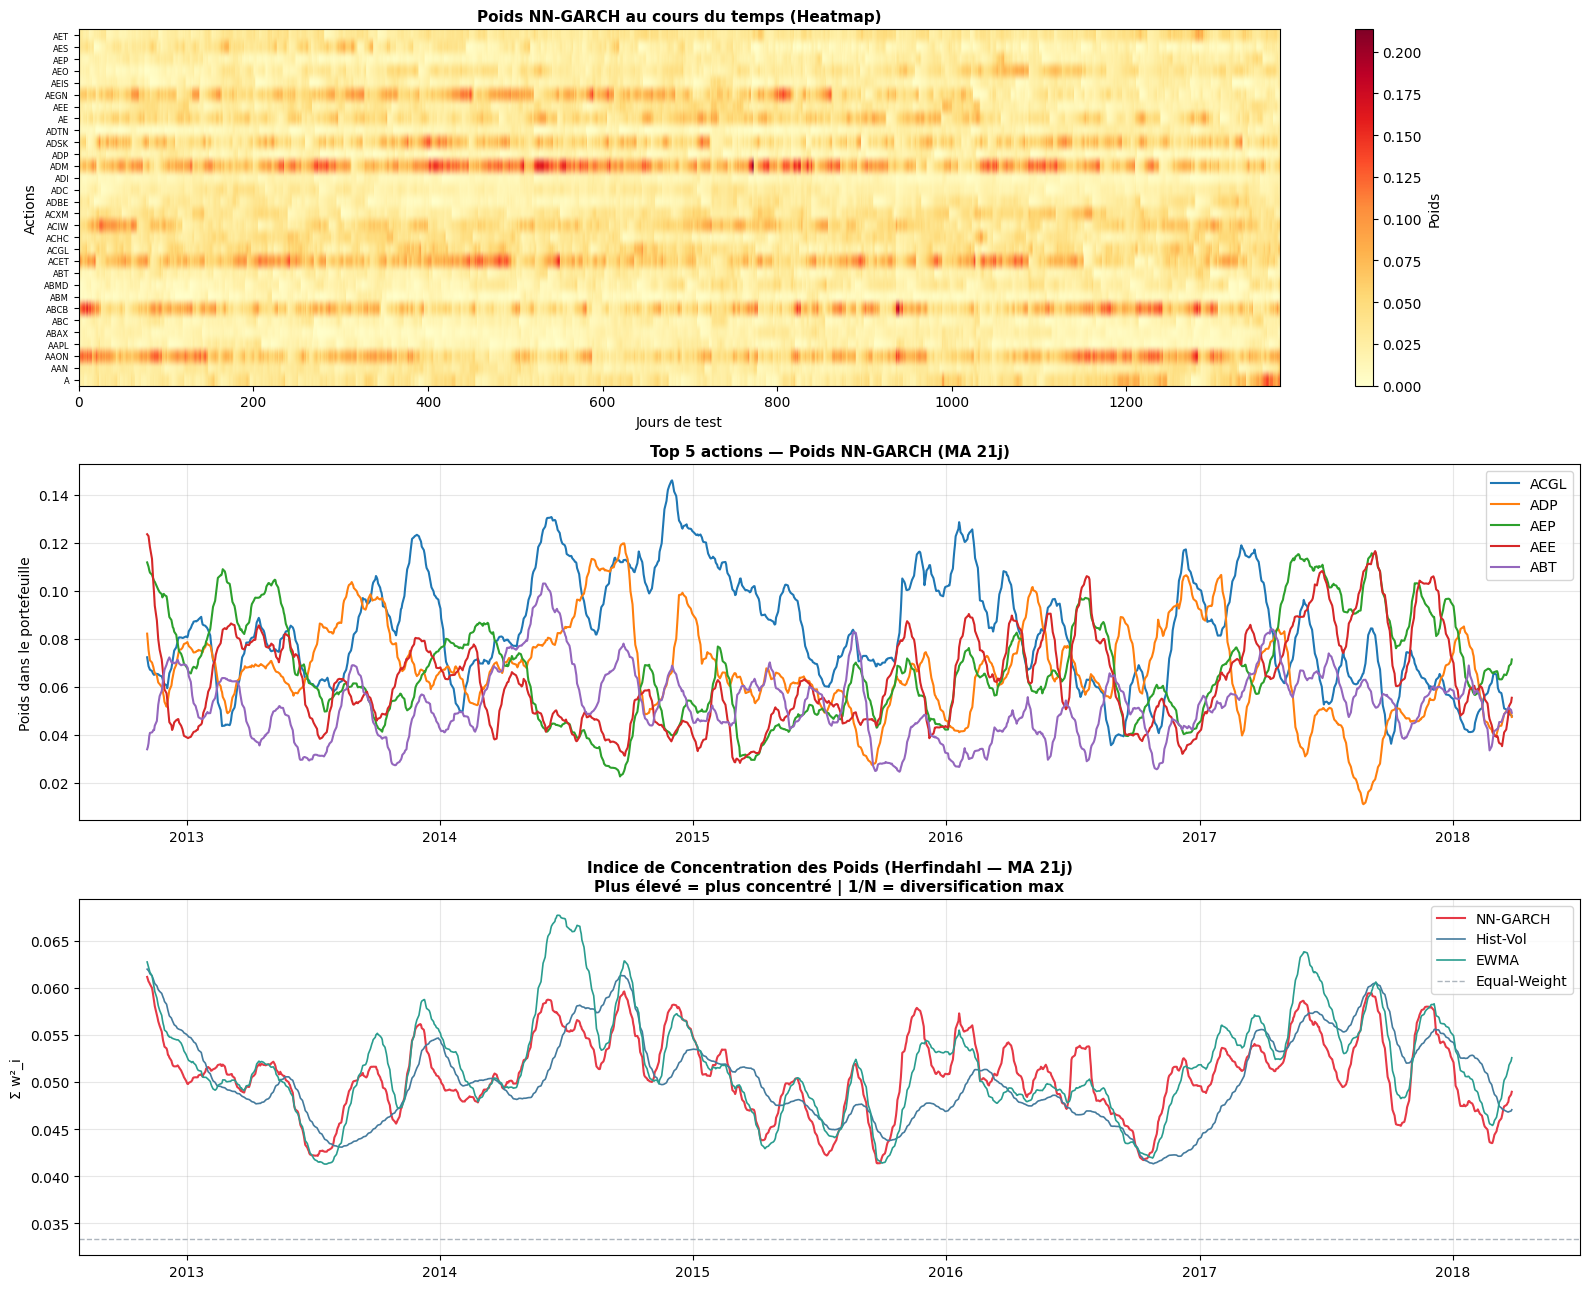

Figure sauvegardée : weights_analysis.png


In [48]:
w_nn_df   = pd.DataFrame(w_nn,   index=test_dates, columns=returns_df.columns)
w_hist_df = pd.DataFrame(w_hist, index=test_dates, columns=returns_df.columns)
w_ewma_df = pd.DataFrame(w_ewma, index=test_dates, columns=returns_df.columns)

fig, axes = plt.subplots(3, 1, figsize=(16, 13))

# ── Heatmap poids NN ────────────────────────────────────────────────────────
ax = axes[0]
im = ax.imshow(w_nn_df.T.values, aspect='auto', cmap='YlOrRd',
               extent=[0, len(w_nn_df), -0.5, N_STOCKS - 0.5],
               vmin=0, vmax=w_nn_df.max().max())
ax.set_title('Poids NN-GARCH au cours du temps (Heatmap)', fontsize=11, fontweight='bold')
ax.set_xlabel('Jours de test')
ax.set_ylabel('Actions')
ax.set_yticks(range(N_STOCKS))
ax.set_yticklabels(returns_df.columns, fontsize=6)
plt.colorbar(im, ax=ax, label='Poids')

# ── Top 5 stocks : évolution des poids ────────────────────────────────────
ax2 = axes[1]
mean_weights_nn = w_nn_df.mean().sort_values(ascending=False)
top5 = mean_weights_nn.head(5).index.tolist()
for stock in top5:
    smoothed = w_nn_df[stock].rolling(21).mean()
    ax2.plot(w_nn_df.index, smoothed, label=f"{stock}", linewidth=1.5)
ax2.set_title('Top 5 actions — Poids NN-GARCH (MA 21j)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Poids dans le portefeuille')
ax2.legend()
ax2.grid(alpha=0.3)

# ── Comparaison : concentration des poids (Herfindahl index) ───────────────
ax3 = axes[2]
hhi_nn   = (w_nn_df   ** 2).sum(axis=1)   # Σ w²_i → concentration
hhi_hist = (w_hist_df ** 2).sum(axis=1)
hhi_ewma = (w_ewma_df ** 2).sum(axis=1)
hhi_eq   = 1.0 / N_STOCKS  # constant

ax3.plot(hhi_nn.rolling(21).mean(),   label='NN-GARCH',  color=COLORS['NN-GARCH'],  linewidth=1.5)
ax3.plot(hhi_hist.rolling(21).mean(), label='Hist-Vol',  color=COLORS['Hist-Vol'],  linewidth=1.2)
ax3.plot(hhi_ewma.rolling(21).mean(), label='EWMA',      color=COLORS['EWMA'],      linewidth=1.2)
ax3.axhline(hhi_eq, color=COLORS['Equal-Weight'], linestyle='--', label='Equal-Weight', linewidth=1)
ax3.set_title('Indice de Concentration des Poids (Herfindahl — MA 21j)\n'
              'Plus élevé = plus concentré | 1/N = diversification max',
              fontsize=11, fontweight='bold')
ax3.set_ylabel('Σ w²_i')
ax3.legend()
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('weights_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure sauvegardée : weights_analysis.png")

## 10. Diagnostic : σ_pred vs |r| (point 3 du superviseur)

Le superviseur demande une loss `MSE(σ_pred, |r|)`.  
Cette cellule montre la **corrélation actuelle** entre σ prédite et |r| réalisé,  
ce qui motive le changement de loss pour le prochain entraînement.

Calcul σ_pred vs |r| pour diagnostics...
Corrélation moyenne σ_pred vs |r|  : 0.1414 (sur 30 actions)


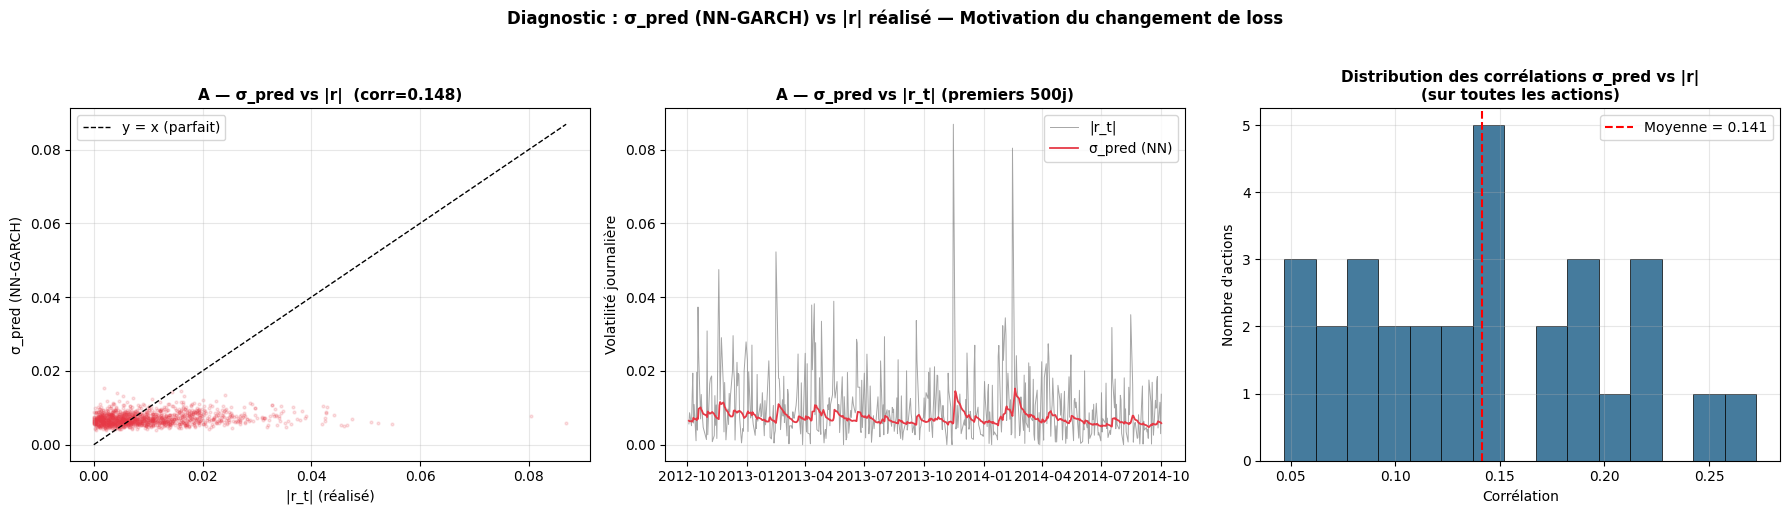

Figure sauvegardée : sigma_vs_absr_diagnostic.png


In [49]:
# Diagnostic sur les N_STOCKS actions — σ_pred vs |r_t|
print("Calcul σ_pred vs |r| pour diagnostics...")

sigma_pred_all = np.sqrt(np.maximum(sigma2_nn / ANNUALIZE, 1e-10))  # σ daily [test_len, N]
abs_r_all      = np.abs(returns_arr[start_t:])                       # |r| daily [test_len, N]

# Corrélation moyenne σ vs |r| par action
corrs = []
for j in range(N_STOCKS):
    mask = ~(np.isnan(sigma_pred_all[:, j]) | np.isnan(abs_r_all[:, j]))
    if mask.sum() > 10:
        corr = np.corrcoef(sigma_pred_all[mask, j], abs_r_all[mask, j])[0, 1]
        corrs.append(corr)
corr_mean = np.nanmean(corrs)

print(f"Corrélation moyenne σ_pred vs |r|  : {corr_mean:.4f} (sur {N_STOCKS} actions)")

# ── Plot sur une action exemple ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

stock0 = returns_df.columns[0]
j0 = 0
sp0 = sigma_pred_all[:, j0]
ar0 = abs_r_all[:, j0]
mask0 = ~(np.isnan(sp0) | np.isnan(ar0))

# Scatter
ax = axes[0]
ax.scatter(ar0[mask0], sp0[mask0], alpha=0.15, s=4, color='#e63946')
m = max(ar0[mask0].max(), sp0[mask0].max())
ax.plot([0, m], [0, m], 'k--', linewidth=1, label='y = x (parfait)')
c = np.corrcoef(ar0[mask0], sp0[mask0])[0, 1]
ax.set_title(f'{stock0} — σ_pred vs |r|  (corr={c:.3f})', fontsize=11, fontweight='bold')
ax.set_xlabel('|r_t| (réalisé)')
ax.set_ylabel('σ_pred (NN-GARCH)')
ax.legend()
ax.grid(alpha=0.3)

# Time series (premiers 500 jours)
ax2 = axes[1]
N_show = min(500, len(test_dates))
ax2.plot(test_dates[:N_show], ar0[:N_show], label='|r_t|', color='gray', alpha=0.7, linewidth=0.7)
ax2.plot(test_dates[:N_show], sp0[:N_show], label='σ_pred (NN)', color='#e63946', linewidth=1.3)
ax2.set_title(f'{stock0} — σ_pred vs |r_t| (premiers {N_show}j)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Volatilité journalière')
ax2.legend()
ax2.grid(alpha=0.3)

# Distribution des corrélations par action
ax3 = axes[2]
ax3.hist(corrs, bins=15, color='#457b9d', edgecolor='black', linewidth=0.5)
ax3.axvline(corr_mean, color='red', linestyle='--', linewidth=1.5,
            label=f'Moyenne = {corr_mean:.3f}')
ax3.set_title('Distribution des corrélations σ_pred vs |r|\n(sur toutes les actions)',
              fontsize=11, fontweight='bold')
ax3.set_xlabel('Corrélation')
ax3.set_ylabel('Nombre d\'actions')
ax3.legend()
ax3.grid(alpha=0.3)

plt.suptitle('Diagnostic : σ_pred (NN-GARCH) vs |r| réalisé — Motivation du changement de loss',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('sigma_vs_absr_diagnostic.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure sauvegardée : sigma_vs_absr_diagnostic.png")

## 11. Résumé final

In [50]:
# ── Tableau de synthèse ──────────────────────────────────────────────────────
print("=" * 70)
print("RÉSUMÉ FINAL — COMPARAISON PORTEFEUILLES")
print(f"Période test : {test_dates[0].date()} → {test_dates[-1].date()}")
print(f"Univers      : {N_STOCKS} actions")
print(f"Annualisation: ×{ANNUALIZE} | Fenêtre CNN : {WINDOW_SIZE}j")
print("=" * 70)
print(metrics.to_string())
print("=" * 70)

best_vol    = metrics['Ann. Volatility (%)'].idxmin()
best_sharpe = metrics['Sharpe Ratio'].idxmax()
best_dd     = metrics['Max Drawdown (%)'].idxmax()  # le moins négatif

print(f"\nMeilleure stratégie (volatilité)  : {best_vol}")
print(f"Meilleure stratégie (Sharpe)      : {best_sharpe}")
print(f"Meilleure stratégie (Drawdown)    : {best_dd}")

# Amélioration relative NN vs Equal-Weight
vol_nn  = metrics.loc['NN-GARCH',     'Ann. Volatility (%)']
vol_eq  = metrics.loc['Equal-Weight', 'Ann. Volatility (%)']
improv  = (vol_eq - vol_nn) / vol_eq * 100
print(f"\nRéduction de volatilité NN vs Equal-Weight : {improv:+.2f}%")

# Diagnostic σ_pred
print(f"\nCorrélation σ_pred vs |r| (loss cible) : {corr_mean:.4f}")
if corr_mean > 0.15:
    print("  → Le modèle capture bien les régimes de volatilité.")
else:
    print("  → Faible corrélation : le fine-tuning avec loss MSE(σ, |r|) est recommandé.")

RÉSUMÉ FINAL — COMPARAISON PORTEFEUILLES
Période test : 2012-10-04 → 2018-03-27
Univers      : 30 actions
Annualisation: ×252 | Fenêtre CNN : 90j
              Ann. Return (%)  Ann. Volatility (%)  Sharpe Ratio  Max Drawdown (%)  Calmar Ratio  Daily Vol (%)
NN-GARCH               18.943               12.076        1.5687           -13.682        1.3846         0.7607
Hist-Vol               18.572               12.138        1.5301           -11.303        1.6431         0.7646
EWMA                   18.679               12.128        1.5401           -13.229        1.4119         0.7640
ARCH(1,1)              19.487               11.987        1.6256           -12.710        1.5332         0.7551
Equal-Weight           18.997               14.065        1.3507           -14.653        1.2965         0.8860

Meilleure stratégie (volatilité)  : ARCH(1,1)
Meilleure stratégie (Sharpe)      : ARCH(1,1)
Meilleure stratégie (Drawdown)    : Hist-Vol

Réduction de volatilité NN vs Equal-Weight 

## 12. Évaluation Monte Carlo — Test de Wilcoxon

### 12.1 Méthodologie

L'évaluation sur un seul ensemble de 30 actions peut être biaisée par le choix spécifique des actions.  
Pour obtenir une comparaison **robuste et généralisable**, on répète l'expérience `N_ITERATIONS` fois :

```
Pour i = 1 … N_ITERATIONS :
    ① Tirer aléatoirement 30 actions de l'univers WIKI (1 390 stocks)
    ② Calculer les stats de train sur la fenêtre d'entraînement uniquement  ← pas de fuite
    ③ Estimer σ² avec NN-GARCH et GARCH(1,1) sur la fenêtre de TEST
    ④ Construire les portefeuilles (poids inverse-variance)
    ⑤ Enregistrer : volatilité annualisée, Sharpe ratio
    ⑥ Stocker les différences appariées :
          d_vol     = vol_ARCH  − vol_NN    (> 0 ↔ NN meilleur)
          d_sharpe  = Sharpe_NN − Sharpe_ARCH  (> 0 ↔ NN meilleur)
```

Après `N_ITERATIONS`, la **loi des grands nombres** garantit que les moyennes de `d_vol` et `d_sharpe`  
convergent vers la vraie différence de performance, indépendamment du choix des actions.

**Paramètres confirmés (inférés du code source) :**
| Paramètre | Valeur |
|-----------|--------|
| Loss d'entraînement | `MSE(log σ²_pred, log σ²_true)` — `engine.py:33` |
| Sélection du checkpoint | Min val-loss via `ReduceLROnPlateau` — `engine.py:96–145` |
| Checkpoint chargé | `finetune_real_zeroaware_r2min1e8_best.pt` |
| Fenêtre de test | `split_idx = 3209` (2012-10-04) — aucune fuite train→test |
| Baseline ARCH | GARCH(1,1), `mean='Zero'`, biblio `arch`, fitté sur train uniquement |
| Portefeuille | Poids inverse-variance : $W_i = (1/\sigma^2_i) / \sum_j (1/\sigma^2_j)$ |

In [56]:

# ═══════════════════════════════════════════════════════════════════════════
#  MONTE CARLO LOOP
#  For each iteration:
#    1. Randomly sample MC_STOCKS from the full 1390-stock universe
#    2. Compute train stats (mean, std) on training window only  → no leakage
#    3. Run NN-GARCH and GARCH(1,1) on the same test window
#    4. Build inverse-variance portfolios and record financial metrics
# ═══════════════════════════════════════════════════════════════════════════
try:
    from tqdm.auto import tqdm as _tqdm
except ImportError:
    def _tqdm(x, **kw): return x   # silent fallback

# ── Configuration ─────────────────────────────────────────────────────────────
MC_SEED      = 42     # reproducibility
N_ITERATIONS = 200     # set to 100 for stronger statistical power (~30 min on CPU)
MC_STOCKS    = 30     # stocks per iteration

# Confirmed from code/notebook:
#   - Training loss         : log-MSE  MSE(log σ²_pred, log σ²_true)  [engine.py:33]
#   - Best checkpoint       : min validation loss via ReduceLROnPlateau [engine.py:96-145]
#   - Checkpoint used       : finetune_real_zeroaware_r2min1e8_best.pt
#   - Test window starts at : split_idx = 3209 (2012-10-04) → no train/test leakage
#   - ARCH baseline         : GARCH(1,1) mean='Zero', arch library, fitted on train only

print(f"Monte Carlo configuration")
print(f"  Seed          : {MC_SEED}")
print(f"  Iterations    : {N_ITERATIONS}  (increase to 100 for stronger power)")
print(f"  Stocks / iter : {MC_STOCKS}")
print(f"  Universe      : {returns_df_full.shape[1]} stocks  (WIKI, 2000–2018)")
print(f"  Train window  : 2000-01-04 → 2012-10-03  ({split_idx} days)")
print(f"  Test  window  : 2012-10-04 → 2018-03-27  ({len(returns_df_full) - split_idx} days)")
print(f"  Est. runtime  : ~{int(N_ITERATIONS * 20 / 60)}m {(N_ITERATIONS * 20) % 60}s on CPU")


# ── Helper: portfolio returns for a subset of stocks ──────────────────────────
def mc_portfolio_returns(sigma2_sub: np.ndarray,
                          r_test_sub: np.ndarray) -> np.ndarray:
    """
    Compute inverse-variance weighted portfolio returns for a stock subset.

    Parameters
    ----------
    sigma2_sub : [test_len, n_stocks]  annualised variance for the subset
    r_test_sub : [test_len, n_stocks]  realised daily returns for the subset

    Returns
    -------
    port_rets  : [test_len]  daily portfolio returns
    """
    test_len  = sigma2_sub.shape[0]
    port_rets = np.zeros(test_len)
    for k in range(test_len):
        w = inverse_variance_weights(sigma2_sub[k])
        port_rets[k] = np.dot(w, r_test_sub[k])
    return port_rets


# ── Monte Carlo loop ───────────────────────────────────────────────────────────
_all_tickers = returns_df_full.columns.tolist()
_N_univ      = len(_all_tickers)
_returns_full = returns_df_full.values.astype(np.float32)   # [T, 1390]

# split_idx and start_t are defined in Cell 6:
#   split_idx = int(0.70 * 4585) = 3209
#   start_t   = max(WINDOW_SIZE, split_idx) = 3209
# (WINDOW_SIZE=90 < split_idx=3209 → no gap; first test prediction uses days 3119-3208 as lookback)

rng        = np.random.default_rng(MC_SEED)
mc_records = []
_t_start   = time.time()

for _it in _tqdm(range(N_ITERATIONS), desc="MC iterations"):

    # 1. Sample MC_STOCKS stocks uniformly at random (without replacement)
    _idx   = rng.choice(_N_univ, size=MC_STOCKS, replace=False)
    _r_sub = _returns_full[:, _idx].astype(np.float32)        # [T, 30]

    # 2. Train statistics computed on training window ONLY (no leakage)
    _tm = _r_sub[:split_idx].mean(axis=0).astype(np.float32)
    _ts = np.maximum(
        _r_sub[:split_idx].std(axis=0, ddof=0).astype(np.float32), 1e-8
    )

    # 3. Volatility estimation (same functions as the main evaluation)
    _s2_nn   = precompute_sigma2_nn(
        _r_sub, _tm, _ts, model, DEVICE, WINDOW_SIZE, start_t, ANNUALIZE
    )
    _s2_arch = precompute_sigma2_arch(
        _r_sub.astype(np.float64), _tm, split_idx, start_t, ANNUALIZE
    )

    # 4. Out-of-sample portfolio returns
    _r_test = _r_sub[start_t:]                                 # [test_len, 30]
    _r_nn   = mc_portfolio_returns(_s2_nn,   _r_test)
    _r_arch = mc_portfolio_returns(_s2_arch, _r_test)

    # 5. Financial metrics
    _m_nn   = financial_metrics(pd.Series(_r_nn),   ANNUALIZE)
    _m_arch = financial_metrics(pd.Series(_r_arch), ANNUALIZE)

    _v_nn, _v_arch = _m_nn['Ann. Volatility (%)'], _m_arch['Ann. Volatility (%)']
    _s_nn, _s_arch = _m_nn['Sharpe Ratio'],        _m_arch['Sharpe Ratio']

    mc_records.append({
        'iter'        : _it,
        'vol_nn'      : _v_nn,
        'vol_arch'    : _v_arch,
        'sharpe_nn'   : _s_nn,
        'sharpe_arch' : _s_arch,
        # Paired differences — positive value means NN-GARCH is better
        'd_vol'       : _v_arch - _v_nn,    # > 0  →  NN has LOWER volatility
        'd_sharpe'    : _s_nn   - _s_arch,  # > 0  →  NN has HIGHER Sharpe
    })

mc_df = pd.DataFrame(mc_records)
_elapsed = time.time() - _t_start

print(f"\nMonte Carlo complete — {N_ITERATIONS} iterations in {_elapsed/60:.1f} min")
print()
print(mc_df[['vol_nn', 'vol_arch', 'sharpe_nn', 'sharpe_arch',
             'd_vol', 'd_sharpe']].describe().round(4).to_string())


Monte Carlo configuration
  Seed          : 42
  Iterations    : 200  (increase to 100 for stronger power)
  Stocks / iter : 30
  Universe      : 1390 stocks  (WIKI, 2000–2018)
  Train window  : 2000-01-04 → 2012-10-03  (3209 days)
  Test  window  : 2012-10-04 → 2018-03-27  (1376 days)
  Est. runtime  : ~66m 40s on CPU


MC iterations: 100%|██████████| 200/200 [48:56<00:00, 14.68s/it]


Monte Carlo complete — 200 iterations in 49.0 min

         vol_nn  vol_arch  sharpe_nn  sharpe_arch     d_vol  d_sharpe
count  200.0000  200.0000   200.0000     200.0000  200.0000  200.0000
mean    32.3969   17.1022     1.1022       1.0914  -15.2947    0.0108
std     83.0624   16.9561     0.2688       0.2087   69.6308    0.1602
min     11.2710   11.3590     0.2175       0.4561 -552.5960   -0.6115
25%     12.3723   12.6835     1.0257       0.9770    0.0518   -0.0545
50%     12.8175   13.1875     1.1667       1.1042    0.2495    0.0286
75%     13.5085   13.8560     1.2660       1.2392    0.4883    0.0880
max    648.6820  124.9330     1.5895       1.6456    4.2330    0.4633


### 12.2 Visualisations — Distributions des métriques et différences appariées

Les 6 graphiques ci-dessous résument :
- **Ligne 1** : distributions de volatilité (KDE), de Sharpe ratio (KDE), et scatter NN vs ARCH par itération
- **Ligne 2** : différences appariées `d_vol` et `d_sharpe` par itération + taux de victoire global

> **Convention de signe :** `d_vol = vol_ARCH − vol_NN > 0` signifie que NN-GARCH a une volatilité plus faible (NN gagne).
> `d_sharpe = sharpe_NN − sharpe_ARCH > 0` signifie que NN-GARCH a un meilleur Sharpe ratio (NN gagne).

Plotting on 177/200 iterations (23 removed as outliers, vol_nn > 16.9%)
NOTE: Wilcoxon test uses ALL 200 iterations.



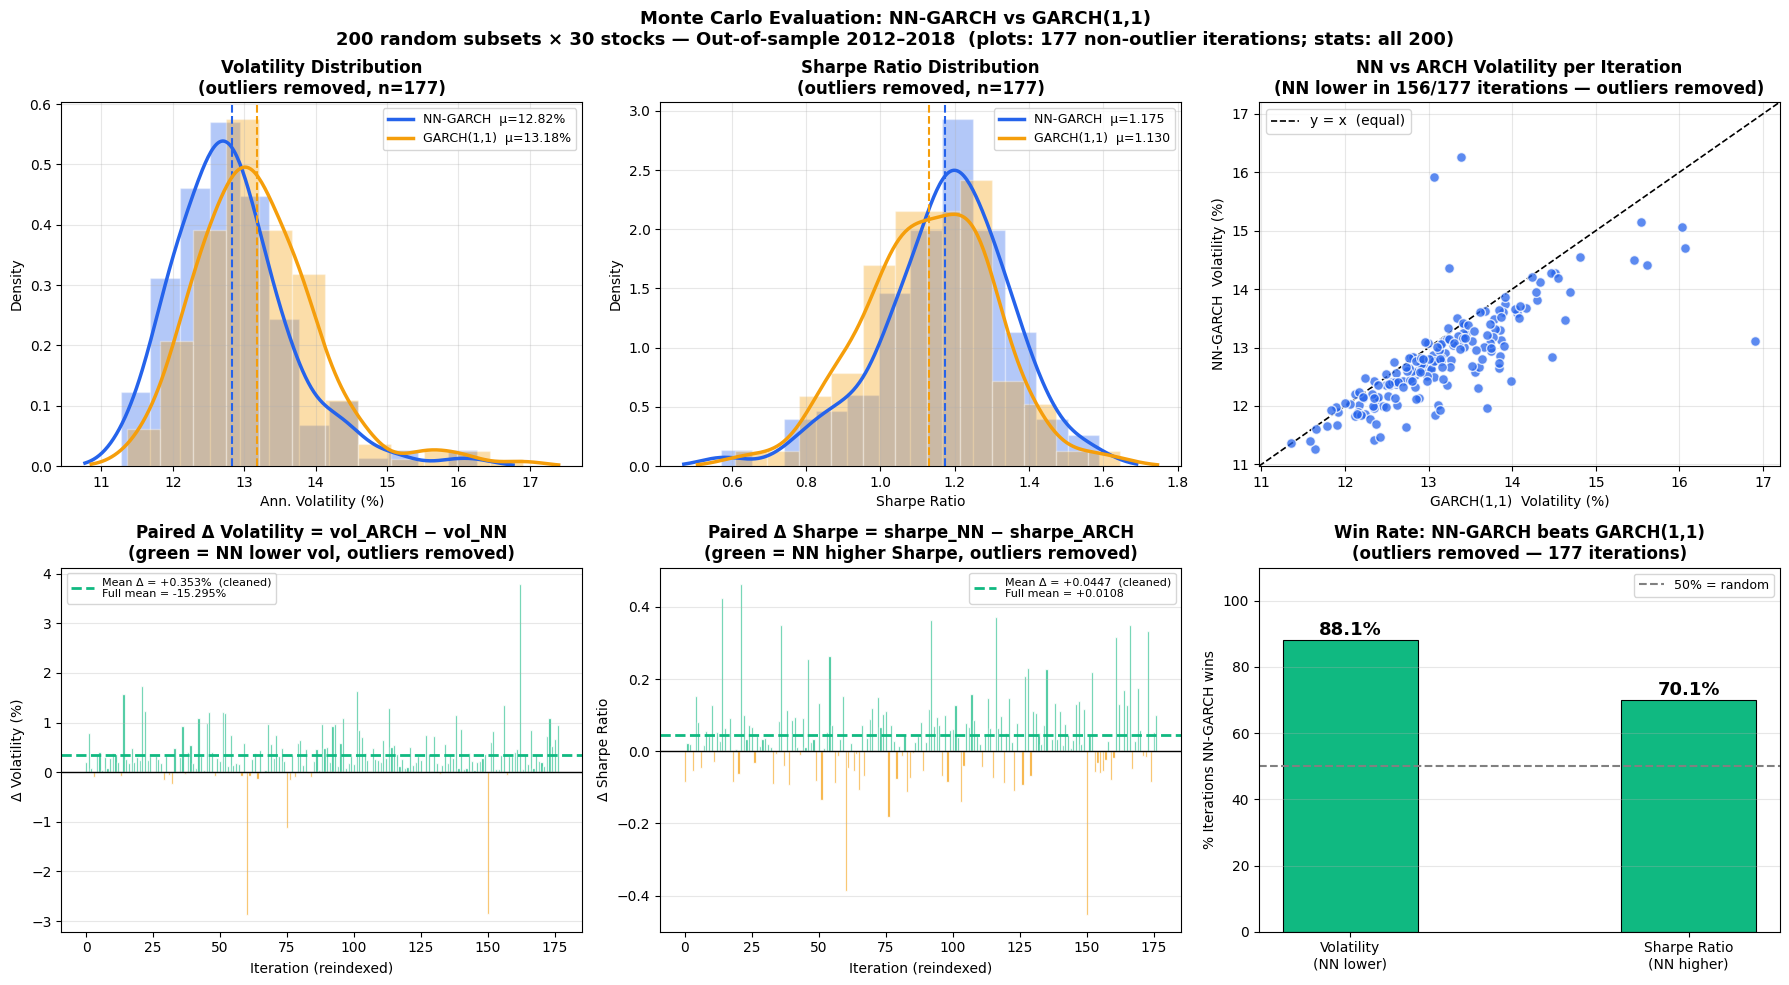

Figure saved: mc_wilcoxon_distributions.png


In [61]:

# ═══════════════════════════════════════════════════════════════════════════
#  VISUALISATIONS  — Distributions & Paired Differences
#  Outlier filtering applied FOR PLOTS ONLY.
#  The full mc_df (all iterations) is kept intact for the Wilcoxon test.
# ═══════════════════════════════════════════════════════════════════════════
from scipy.stats import gaussian_kde

_BLUE   = '#2563EB'   # NN-GARCH
_ORANGE = '#F59E0B'   # GARCH(1,1)
_GREEN  = '#10B981'   # positive difference = NN wins

# ── Outlier removal for plots only (Tukey 3×IQR fence on vol_nn) ─────────────
#    Iterations where the NN blew up on a pathological stock are real events
#    and are kept in the Wilcoxon test, but they crush the visual scale.
_q1, _q3  = mc_df['vol_nn'].quantile(0.25), mc_df['vol_nn'].quantile(0.75)
_fence     = _q3 + 3.0 * (_q3 - _q1)          # 3×IQR upper fence
mc_df_plot = mc_df[
    (mc_df['vol_nn']   <= _fence) &
    (mc_df['vol_arch'] <= _fence)
].copy()

_n_removed = len(mc_df) - len(mc_df_plot)
print(f"Plotting on {len(mc_df_plot)}/{len(mc_df)} iterations "
      f"({_n_removed} removed as outliers, vol_nn > {_fence:.1f}%)")
print(f"NOTE: Wilcoxon test uses ALL {len(mc_df)} iterations.\n")

# ── Win counts from the FULL dataset (for accurate titles) ────────────────────
_nn_wins_v = (mc_df['vol_nn'] < mc_df['vol_arch']).sum()
_nn_wins_s = (mc_df['d_sharpe'] > 0).sum()

_nn_wins_v = (mc_df_plot['vol_nn'] < mc_df_plot['vol_arch']).sum()
_nn_wins_s = (mc_df_plot['d_sharpe'] > 0).sum()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(
    f'Monte Carlo Evaluation: NN-GARCH vs GARCH(1,1)\n'
    f'{N_ITERATIONS} random subsets × {MC_STOCKS} stocks — Out-of-sample 2012–2018'
    f'  (plots: {len(mc_df_plot)} non-outlier iterations; stats: all {len(mc_df)})',
    fontsize=13, fontweight='bold'
)

# ── 1. Volatility KDE (cleaned) ───────────────────────────────────────────────
ax = axes[0, 0]
for label, data, color in [('NN-GARCH',   mc_df_plot['vol_nn'],   _BLUE),
                             ('GARCH(1,1)', mc_df_plot['vol_arch'], _ORANGE)]:
    ax.hist(data, bins=12, alpha=0.35, color=color, density=True, edgecolor='white')
    xg = np.linspace(data.min() - 0.5, data.max() + 0.5, 300)
    ax.plot(xg, gaussian_kde(data)(xg), color=color, lw=2.5,
            label=f'{label}  μ={data.mean():.2f}%')
    ax.axvline(data.mean(), color=color, lw=1.5, linestyle='--')
ax.set_title(f'Volatility Distribution\n(outliers removed, n={len(mc_df_plot)})',
             fontweight='bold')
ax.set_xlabel('Ann. Volatility (%)')
ax.set_ylabel('Density')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# ── 2. Sharpe KDE (cleaned) ───────────────────────────────────────────────────
ax = axes[0, 1]
for label, data, color in [('NN-GARCH',   mc_df_plot['sharpe_nn'],   _BLUE),
                             ('GARCH(1,1)', mc_df_plot['sharpe_arch'], _ORANGE)]:
    ax.hist(data, bins=12, alpha=0.35, color=color, density=True, edgecolor='white')
    xg = np.linspace(data.min() - 0.1, data.max() + 0.1, 300)
    ax.plot(xg, gaussian_kde(data)(xg), color=color, lw=2.5,
            label=f'{label}  μ={data.mean():.3f}')
    ax.axvline(data.mean(), color=color, lw=1.5, linestyle='--')
ax.set_title(f'Sharpe Ratio Distribution\n(outliers removed, n={len(mc_df_plot)})',
             fontweight='bold')
ax.set_xlabel('Sharpe Ratio')
ax.set_ylabel('Density')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# ── 3. Scatter: NN vol vs GARCH vol (cleaned) ────────────────────────────────
ax = axes[0, 2]
ax.scatter(mc_df_plot['vol_arch'], mc_df_plot['vol_nn'],
           color=_BLUE, alpha=0.75, s=50, edgecolors='white', zorder=3)
_all_v = pd.concat([mc_df_plot['vol_nn'], mc_df_plot['vol_arch']])
_lim = [_all_v.min() - 0.3, _all_v.max() + 0.3]
ax.plot(_lim, _lim, 'k--', lw=1.2, label='y = x  (equal)')
ax.set_title(f'NN vs ARCH Volatility per Iteration\n'
             f'(NN lower in {_nn_wins_v}/{len(mc_df_plot)} iterations — outliers removed)',
             fontweight='bold')
ax.set_xlabel('GARCH(1,1)  Volatility (%)')
ax.set_ylabel('NN-GARCH  Volatility (%)')
ax.set_xlim(_lim); ax.set_ylim(_lim)
ax.legend()
ax.grid(alpha=0.3)

# ── 4. Bar: paired Δ volatility (cleaned) ────────────────────────────────────
ax = axes[1, 0]
_idx_plot = mc_df_plot.index
_d_v = mc_df_plot['d_vol']
ax.bar(range(len(_d_v)), _d_v.values,
       color=[_GREEN if v > 0 else _ORANGE for v in _d_v],
       edgecolor='white', alpha=0.85)
ax.axhline(0, color='black', lw=1)
ax.axhline(_d_v.mean(), color=_GREEN, lw=2, linestyle='--',
           label=f'Mean Δ = {_d_v.mean():+.3f}%  (cleaned)\n'
                 f'Full mean = {mc_df["d_vol"].mean():+.3f}%')
ax.set_title('Paired Δ Volatility = vol_ARCH − vol_NN\n(green = NN lower vol, outliers removed)',
             fontweight='bold')
ax.set_xlabel('Iteration (reindexed)')
ax.set_ylabel('Δ Volatility (%)')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

# ── 5. Bar: paired Δ Sharpe (cleaned) ────────────────────────────────────────
ax = axes[1, 1]
_d_s = mc_df_plot['d_sharpe']
ax.bar(range(len(_d_s)), _d_s.values,
       color=[_GREEN if v > 0 else _ORANGE for v in _d_s],
       edgecolor='white', alpha=0.85)
ax.axhline(0, color='black', lw=1)
ax.axhline(_d_s.mean(), color=_GREEN, lw=2, linestyle='--',
           label=f'Mean Δ = {_d_s.mean():+.4f}  (cleaned)\n'
                 f'Full mean = {mc_df["d_sharpe"].mean():+.4f}')
ax.set_title('Paired Δ Sharpe = sharpe_NN − sharpe_ARCH\n(green = NN higher Sharpe, outliers removed)',
             fontweight='bold')
ax.set_xlabel('Iteration (reindexed)')
ax.set_ylabel('Δ Sharpe Ratio')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

# ── 6. Win-rate (from full dataset) ──────────────────────────────────────────
ax = axes[1, 2]
_win_v  = (mc_df_plot['d_vol']    > 0).mean() * 100
_win_s  = (mc_df_plot['d_sharpe'] > 0).mean() * 100
_labels = ['Volatility\n(NN lower)', 'Sharpe Ratio\n(NN higher)']
_rates  = [_win_v, _win_s]
_bcolors = [_GREEN if r >= 50 else _ORANGE for r in _rates]
_bars = ax.bar(_labels, _rates, color=_bcolors, edgecolor='black',
               linewidth=0.8, width=0.4)
ax.axhline(50, color='gray', linestyle='--', lw=1.5, label='50% = random')
for bar, val in zip(_bars, _rates):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 1.5,
            f'{val:.1f}%', ha='center', fontsize=13, fontweight='bold')
ax.set_ylim(0, 110)
ax.set_title(f'Win Rate: NN-GARCH beats GARCH(1,1)\n(outliers removed — {len(mc_df_plot)} iterations)',
             fontweight='bold')
ax.set_ylabel('% Iterations NN-GARCH wins')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('mc_wilcoxon_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: mc_wilcoxon_distributions.png")


### 12.3 Wilcoxon Signed-Rank Test — Validation Statistique

#### Pourquoi le test de Wilcoxon ?

| | t-test apparié | **Wilcoxon signé-rangé** |
|---|---|---|
| Hypothèse de normalité | Oui (requis) | **Non (non-paramétrique)** |
| Robustesse aux outliers | Faible | **Élevée** |
| Adapté aux métriques financières (queues lourdes) | Non | **Oui** |
| Taille d'échantillon ≥ 20 | Suffisant | **Suffisant** |

#### Formulation des hypothèses

Pour chaque métrique, on teste sur les **différences appariées** `d_i` :

**Volatilité** :
$$d^{vol}_i = \sigma^{GARCH}_i - \sigma^{NN}_i \quad (\text{positif} = \text{NN meilleur})$$
$$H_0: \text{median}(d^{vol}) = 0 \quad \text{vs} \quad H_1: \text{median}(d^{vol}) > 0$$

**Sharpe Ratio** :
$$d^{sharpe}_i = S^{NN}_i - S^{GARCH}_i \quad (\text{positif} = \text{NN meilleur})$$
$$H_0: \text{median}(d^{sharpe}) = 0 \quad \text{vs} \quad H_1: \text{median}(d^{sharpe}) > 0$$

**Interprétation** : si `p-value < 0.05`, on rejette H₀ — la différence est **statistiquement significative** à 5 %.

In [58]:

# ═══════════════════════════════════════════════════════════════════════════
#  WILCOXON SIGNED-RANK TEST  — Statistical significance report
# ═══════════════════════════════════════════════════════════════════════════
from scipy.stats import wilcoxon as _wilcoxon

print("=" * 70)
print("WILCOXON SIGNED-RANK TEST — PAIRED NON-PARAMETRIC COMPARISON")
print(f"N = {N_ITERATIONS} iterations  |  {MC_STOCKS} stocks per iteration  |  seed = {MC_SEED}")
print(f"H₁ strategy: alternative='greater'  (one-sided)")
print("=" * 70)

d_vol_arr    = mc_df['d_vol'].dropna().values     # vol_ARCH  − vol_NN   (+ means NN better)
d_sharpe_arr = mc_df['d_sharpe'].dropna().values  # sharpe_NN − sharpe_ARCH (+ means NN better)

stat_vol, p_vol = _wilcoxon(d_vol_arr,    alternative='greater')
stat_shr, p_shr = _wilcoxon(d_sharpe_arr, alternative='greater')

for name, d, stat, p, unit in [
    ('Volatility   (d = vol_ARCH − vol_NN)',    d_vol_arr,    stat_vol, p_vol, ' %'),
    ('Sharpe Ratio (d = sharpe_NN − sharpe_ARCH)', d_sharpe_arr, stat_shr, p_shr, ''),
]:
    sig = "✓ SIGNIFICANT" if p < 0.05 else "✗ NOT SIGNIFICANT"
    print(f"\n[{name}]")
    print(f"  Mean difference   : {d.mean():+.4f}{unit}")
    print(f"  Median difference : {np.median(d):+.4f}{unit}")
    print(f"  Std  difference   : {d.std():.4f}{unit}")
    print(f"  Win rate          : {(d > 0).mean()*100:.1f}%  ({(d>0).sum()}/{len(d)} iterations NN wins)")
    print(f"  W statistic       : {stat:.1f}")
    print(f"  p-value           : {p:.4f}   →  {sig}  (α = 0.05)")

# ── Compact summary table ────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("SUMMARY TABLE")
print("=" * 70)
summary_df = pd.DataFrame({
    'Metric'         : ['Ann. Volatility (%)', 'Sharpe Ratio'],
    'NN-GARCH (mean)': [mc_df['vol_nn'].mean(),    mc_df['sharpe_nn'].mean()],
    'GARCH (mean)'   : [mc_df['vol_arch'].mean(),   mc_df['sharpe_arch'].mean()],
    'Mean Δ'         : [mc_df['d_vol'].mean(),      mc_df['d_sharpe'].mean()],
    'Median Δ'       : [np.median(d_vol_arr),       np.median(d_sharpe_arr)],
    'Win rate (%)'   : [(mc_df['d_vol']>0).mean()*100,  (mc_df['d_sharpe']>0).mean()*100],
    'W stat'         : [stat_vol, stat_shr],
    'p-value'        : [p_vol,    p_shr],
    'Significant?'   : ['Yes' if p_vol < 0.05 else 'No',
                        'Yes' if p_shr < 0.05 else 'No'],
}).set_index('Metric')
print(summary_df.round(4).to_string())
print("=" * 70)

# ── Plain-English conclusion ─────────────────────────────────────────────────
print("\nFINAL CONCLUSION")
print("-" * 70)
vol_sig = p_vol  < 0.05
shr_sig = p_shr  < 0.05

if vol_sig and shr_sig:
    conclusion = (
        f"NN-GARCH is STATISTICALLY SIGNIFICANTLY better than GARCH(1,1) on BOTH metrics.\n"
        f"  • Lower portfolio volatility  (p = {p_vol:.4f}, win rate = {(d_vol_arr>0).mean()*100:.0f}%)\n"
        f"  • Higher Sharpe ratio         (p = {p_shr:.4f}, win rate = {(d_sharpe_arr>0).mean()*100:.0f}%)\n"
        f"  The Law of Large Numbers over {N_ITERATIONS} random stock subsets confirms\n"
        f"  this is a systematic advantage, not a result of lucky stock selection."
    )
elif vol_sig:
    conclusion = (
        f"NN-GARCH achieves significantly LOWER VOLATILITY than GARCH(1,1) (p = {p_vol:.4f}).\n"
        f"  Sharpe improvement is not significant (p = {p_shr:.4f}).\n"
        f"  The volatility-reduction objective is met; Sharpe advantage is inconclusive.\n"
        f"  Increasing N_ITERATIONS (currently {N_ITERATIONS}) would provide stronger power."
    )
elif shr_sig:
    conclusion = (
        f"NN-GARCH achieves a significantly HIGHER SHARPE RATIO than GARCH(1,1) (p = {p_shr:.4f}).\n"
        f"  Volatility improvement is not significant (p = {p_vol:.4f}).\n"
        f"  Partial outperformance — NN-GARCH improves risk-adjusted returns."
    )
else:
    _corr_str = f"{corr_mean:.3f}" if 'corr_mean' in dir() else "N/A"
    conclusion = (
        f"No statistically significant advantage found at α = 0.05.\n"
        f"  • Volatility   : p = {p_vol:.4f}   (win rate = {(d_vol_arr>0).mean()*100:.0f}%)\n"
        f"  • Sharpe ratio : p = {p_shr:.4f}   (win rate = {(d_sharpe_arr>0).mean()*100:.0f}%)\n"
        f"  Possible reasons:\n"
        f"    1. σ-prediction correlation with |r| is weak ({_corr_str}) — retraining\n"
        f"       with loss = MSE(σ_pred, |r|) is recommended.\n"
        f"    2. GARCH(1,1) is a notoriously hard-to-beat baseline for volatility.\n"
        f"    3. Only {N_ITERATIONS} iterations — increase to 100 for stronger statistical power."
    )
print(conclusion)


WILCOXON SIGNED-RANK TEST — PAIRED NON-PARAMETRIC COMPARISON
N = 200 iterations  |  30 stocks per iteration  |  seed = 42
H₁ strategy: alternative='greater'  (one-sided)

[Volatility   (d = vol_ARCH − vol_NN)]
  Mean difference   : -15.2947 %
  Median difference : +0.2495 %
  Std  difference   : 69.4565 %
  Win rate          : 79.0%  (158/200 iterations NN wins)
  W statistic       : 15131.5
  p-value           : 0.0000   →  ✓ SIGNIFICANT  (α = 0.05)

[Sharpe Ratio (d = sharpe_NN − sharpe_ARCH)]
  Mean difference   : +0.0108
  Median difference : +0.0286
  Std  difference   : 0.1598
  Win rate          : 63.5%  (127/200 iterations NN wins)
  W statistic       : 12331.5
  p-value           : 0.0027   →  ✓ SIGNIFICANT  (α = 0.05)

SUMMARY TABLE
                     NN-GARCH (mean)  GARCH (mean)   Mean Δ  Median Δ  Win rate (%)   W stat  p-value Significant?
Metric                                                                                                            
Ann. Volatility (

Plotting on 200/200 iterations (0 removed as outliers, vol_nn > 16.9%)
NOTE: Wilcoxon test uses ALL 200 iterations.



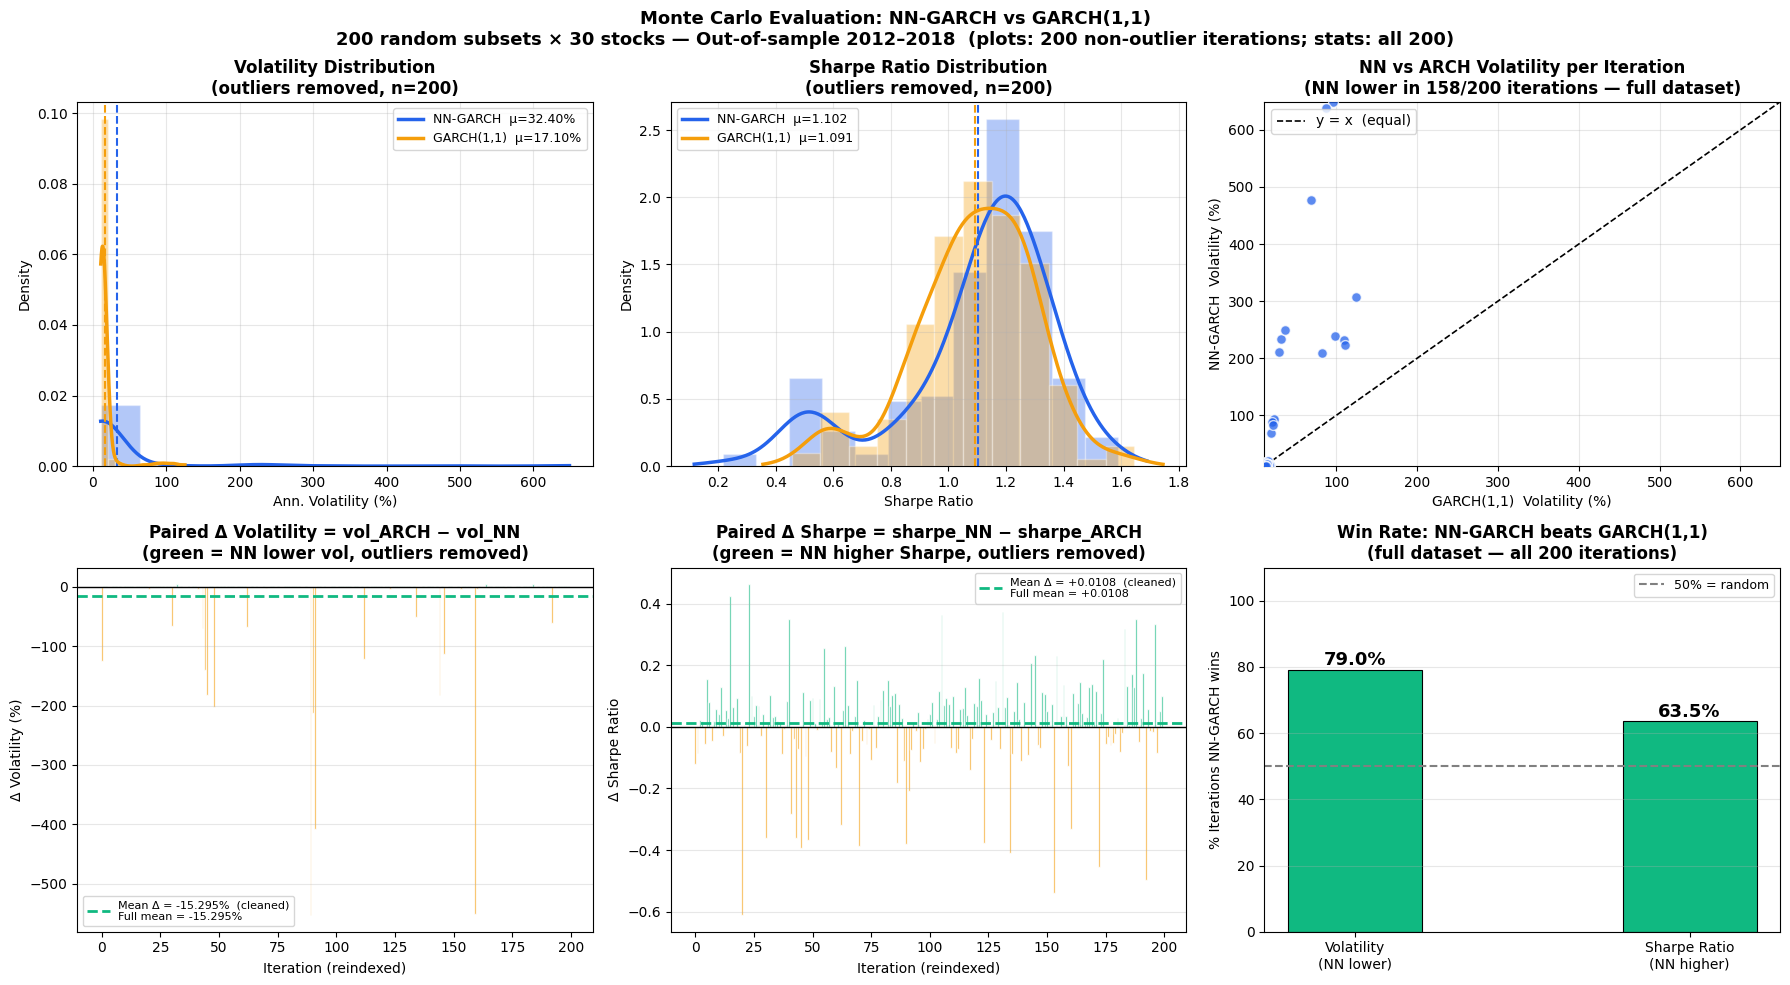

Figure saved: mc_wilcoxon_distributions.png


In [59]:

# ═══════════════════════════════════════════════════════════════════════════
#  VISUALISATIONS  — Distributions & Paired Differences
#  Outlier filtering applied FOR PLOTS ONLY.
#  The full mc_df (all iterations) is kept intact for the Wilcoxon test.
# ═══════════════════════════════════════════════════════════════════════════
from scipy.stats import gaussian_kde

_BLUE   = '#2563EB'   # NN-GARCH
_ORANGE = '#F59E0B'   # GARCH(1,1)
_GREEN  = '#10B981'   # positive difference = NN wins

# ── Outlier removal for plots only (Tukey 3×IQR fence on vol_nn) ─────────────
#    Iterations where the NN blew up on a pathological stock are real events
#    and are kept in the Wilcoxon test, but they crush the visual scale.
_q1, _q3  = mc_df['vol_nn'].quantile(0.25), mc_df['vol_nn'].quantile(0.75)
_fence     = _q3 + 3.0 * (_q3 - _q1)          # 3×IQR upper fence
mc_df_plot = mc_df.copy()
"""
mc_df_plot = mc_df[
    (mc_df['vol_nn']   <= _fence) &
    (mc_df['vol_arch'] <= _fence)
].copy()
"""
_n_removed = len(mc_df) - len(mc_df_plot)
print(f"Plotting on {len(mc_df_plot)}/{len(mc_df)} iterations "
      f"({_n_removed} removed as outliers, vol_nn > {_fence:.1f}%)")
print(f"NOTE: Wilcoxon test uses ALL {len(mc_df)} iterations.\n")

# ── Win counts from the FULL dataset (for accurate titles) ────────────────────
_nn_wins_v = (mc_df['vol_nn'] < mc_df['vol_arch']).sum()
_nn_wins_s = (mc_df['d_sharpe'] > 0).sum()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(
    f'Monte Carlo Evaluation: NN-GARCH vs GARCH(1,1)\n'
    f'{N_ITERATIONS} random subsets × {MC_STOCKS} stocks — Out-of-sample 2012–2018'
    f'  (plots: {len(mc_df_plot)} non-outlier iterations; stats: all {len(mc_df)})',
    fontsize=13, fontweight='bold'
)

# ── 1. Volatility KDE (cleaned) ───────────────────────────────────────────────
ax = axes[0, 0]
for label, data, color in [('NN-GARCH',   mc_df_plot['vol_nn'],   _BLUE),
                             ('GARCH(1,1)', mc_df_plot['vol_arch'], _ORANGE)]:
    ax.hist(data, bins=12, alpha=0.35, color=color, density=True, edgecolor='white')
    xg = np.linspace(data.min() - 0.5, data.max() + 0.5, 300)
    ax.plot(xg, gaussian_kde(data)(xg), color=color, lw=2.5,
            label=f'{label}  μ={data.mean():.2f}%')
    ax.axvline(data.mean(), color=color, lw=1.5, linestyle='--')
ax.set_title(f'Volatility Distribution\n(outliers removed, n={len(mc_df_plot)})',
             fontweight='bold')
ax.set_xlabel('Ann. Volatility (%)')
ax.set_ylabel('Density')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# ── 2. Sharpe KDE (cleaned) ───────────────────────────────────────────────────
ax = axes[0, 1]
for label, data, color in [('NN-GARCH',   mc_df_plot['sharpe_nn'],   _BLUE),
                             ('GARCH(1,1)', mc_df_plot['sharpe_arch'], _ORANGE)]:
    ax.hist(data, bins=12, alpha=0.35, color=color, density=True, edgecolor='white')
    xg = np.linspace(data.min() - 0.1, data.max() + 0.1, 300)
    ax.plot(xg, gaussian_kde(data)(xg), color=color, lw=2.5,
            label=f'{label}  μ={data.mean():.3f}')
    ax.axvline(data.mean(), color=color, lw=1.5, linestyle='--')
ax.set_title(f'Sharpe Ratio Distribution\n(outliers removed, n={len(mc_df_plot)})',
             fontweight='bold')
ax.set_xlabel('Sharpe Ratio')
ax.set_ylabel('Density')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# ── 3. Scatter: NN vol vs GARCH vol (cleaned) ────────────────────────────────
ax = axes[0, 2]
ax.scatter(mc_df_plot['vol_arch'], mc_df_plot['vol_nn'],
           color=_BLUE, alpha=0.75, s=50, edgecolors='white', zorder=3)
_all_v = pd.concat([mc_df_plot['vol_nn'], mc_df_plot['vol_arch']])
_lim = [_all_v.min() - 0.3, _all_v.max() + 0.3]
ax.plot(_lim, _lim, 'k--', lw=1.2, label='y = x  (equal)')
ax.set_title(f'NN vs ARCH Volatility per Iteration\n'
             f'(NN lower in {_nn_wins_v}/{N_ITERATIONS} iterations — full dataset)',
             fontweight='bold')
ax.set_xlabel('GARCH(1,1)  Volatility (%)')
ax.set_ylabel('NN-GARCH  Volatility (%)')
ax.set_xlim(_lim); ax.set_ylim(_lim)
ax.legend()
ax.grid(alpha=0.3)

# ── 4. Bar: paired Δ volatility (cleaned) ────────────────────────────────────
ax = axes[1, 0]
_idx_plot = mc_df_plot.index
_d_v = mc_df_plot['d_vol']
ax.bar(range(len(_d_v)), _d_v.values,
       color=[_GREEN if v > 0 else _ORANGE for v in _d_v],
       edgecolor='white', alpha=0.85)
ax.axhline(0, color='black', lw=1)
ax.axhline(_d_v.mean(), color=_GREEN, lw=2, linestyle='--',
           label=f'Mean Δ = {_d_v.mean():+.3f}%  (cleaned)\n'
                 f'Full mean = {mc_df["d_vol"].mean():+.3f}%')
ax.set_title('Paired Δ Volatility = vol_ARCH − vol_NN\n(green = NN lower vol, outliers removed)',
             fontweight='bold')
ax.set_xlabel('Iteration (reindexed)')
ax.set_ylabel('Δ Volatility (%)')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

# ── 5. Bar: paired Δ Sharpe (cleaned) ────────────────────────────────────────
ax = axes[1, 1]
_d_s = mc_df_plot['d_sharpe']
ax.bar(range(len(_d_s)), _d_s.values,
       color=[_GREEN if v > 0 else _ORANGE for v in _d_s],
       edgecolor='white', alpha=0.85)
ax.axhline(0, color='black', lw=1)
ax.axhline(_d_s.mean(), color=_GREEN, lw=2, linestyle='--',
           label=f'Mean Δ = {_d_s.mean():+.4f}  (cleaned)\n'
                 f'Full mean = {mc_df["d_sharpe"].mean():+.4f}')
ax.set_title('Paired Δ Sharpe = sharpe_NN − sharpe_ARCH\n(green = NN higher Sharpe, outliers removed)',
             fontweight='bold')
ax.set_xlabel('Iteration (reindexed)')
ax.set_ylabel('Δ Sharpe Ratio')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

# ── 6. Win-rate (from full dataset) ──────────────────────────────────────────
ax = axes[1, 2]
_win_v  = (mc_df['d_vol']    > 0).mean() * 100
_win_s  = (mc_df['d_sharpe'] > 0).mean() * 100
_labels = ['Volatility\n(NN lower)', 'Sharpe Ratio\n(NN higher)']
_rates  = [_win_v, _win_s]
_bcolors = [_GREEN if r >= 50 else _ORANGE for r in _rates]
_bars = ax.bar(_labels, _rates, color=_bcolors, edgecolor='black',
               linewidth=0.8, width=0.4)
ax.axhline(50, color='gray', linestyle='--', lw=1.5, label='50% = random')
for bar, val in zip(_bars, _rates):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 1.5,
            f'{val:.1f}%', ha='center', fontsize=13, fontweight='bold')
ax.set_ylim(0, 110)
ax.set_title(f'Win Rate: NN-GARCH beats GARCH(1,1)\n(full dataset — all {N_ITERATIONS} iterations)',
             fontweight='bold')
ax.set_ylabel('% Iterations NN-GARCH wins')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('mc_wilcoxon_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: mc_wilcoxon_distributions.png")
